In [24]:
import point_cloud_utils as pcu
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [38]:
"""
Normalize a point cloud so that it's centered at the origin and fits inside a unit sphere.
"""
def normalize_point_cloud(points):
    """
    Normalizes a point cloud.
    
    Parameters:
    -----------
    points : np.ndarray
        Array of shape (N, 3) representing the point cloud.
    
    Returns:
    --------
    np.ndarray
        The normalized point cloud.
    """
    centroid = np.mean(points, axis=0)
    points = points - centroid
    max_dist = np.max(np.linalg.norm(points, axis=1))
    normalized_points = points / max_dist
    return normalized_points

In [25]:
'''
S_r Load references meshes dataset
'''

import sys
sys.path.append('/root/multi-3D')  # Add project root to Python path
from datasets.shapenet_lamp import Dataset
from argparse import Namespace

args = Namespace(
    n_max_triangles=800,  # Set your desired value
    # Add any other required arguments that the Dataset class needs
    pad_id=-1,
    n_discrete_size=128,
    augment=False
)

reference_dataset = Dataset(args=args, split_set="val", augment=False)
print("Number of reference meshes:", len(reference_dataset))

100%|██████████| 112/112 [00:00<00:00, 2418.42it/s]

[MeshDataset] Created from 62 shapes for shapenet_lamp val
Number of reference meshes: 62


In [39]:
'''
S_r := Sample points from reference meshes dataset to create reference point clouds
'''
import point_cloud_utils as pcu
from tqdm import tqdm

reference_point_clouds = []
print(len(reference_dataset))
for mesh in tqdm(range(len(reference_dataset)), desc="Sampling reference meshes"):
    v = reference_dataset[mesh]["vertices"]  # shape (Nv, 3)
    f = reference_dataset[mesh]["faces"]     # shape (Nf, 3)
    fid, bc = pcu.sample_mesh_random(v, f, num_samples=2048)
    sampled_points = pcu.interpolate_barycentric_coords(f, fid, bc, v)
    reference_point_clouds.append(sampled_points.astype(np.float32))

reference_point_clouds = np.array(reference_point_clouds)
print(f"Number of sampled pointclouds from reference meshes: {len(reference_point_clouds)}")
print("reference_point_clouds shape: ", reference_point_clouds.shape)


62


Sampling reference meshes: 100%|██████████| 62/62 [00:00<00:00, 625.54it/s]

Number of sampled pointclouds from reference meshes: 62
reference_point_clouds shape:  (62, 2048, 3)


In [40]:
"""
Normalization of reference point clouds
"""
normalized_reference_point_clouds = np.array([normalize_point_cloud(pc) for pc in reference_point_clouds])
print("normalized_reference_point_clouds shape: ", normalized_reference_point_clouds.shape)
print("normalized_reference_point_clouds[0]: ", normalized_reference_point_clouds[0])


normalized_reference_point_clouds shape:  (62, 2048, 3)
normalized_reference_point_clouds[0]:  [[ 0.2023394  -0.02653766 -0.1979113 ]
 [ 0.03490784 -0.59189034 -0.01628513]
 [ 0.10639183  0.16479166  0.26114857]
 ...
 [-0.24523084  0.28500634  0.1423251 ]
 [ 0.0692804   0.55657756  0.16899903]
 [ 0.05775377  0.14449045 -0.2790084 ]]


In [41]:
'''
S_g := Sample points from generated meshes dataset to create generated point clouds
'''
import os
import trimesh
import point_cloud_utils as pcu
import numpy as np
from tqdm import tqdm

PATH_TO_GENERATED_MESHES = "/root/multi-3D/output-finetune-mesh-xl/sampled"

# Initialize an empty list to store sampled points
generated_point_clouds = []

# Wrap the list of files with tqdm for a progress bar
files_list = [f for f in os.listdir(PATH_TO_GENERATED_MESHES) if f.endswith(".ply")]
for file in tqdm(files_list, desc="Sampling generated meshes"):
    file_path = os.path.join(PATH_TO_GENERATED_MESHES, file)
    
    # Try to force load as a mesh
    try:
        mesh = trimesh.load(file_path, force='mesh')
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue

    # If the mesh is empty, skip it.
    if mesh.vertices.shape[0] == 0 or mesh.faces.shape[0] == 0:
        print(f"Mesh {file} is empty. Skipping...")
        continue
    
    # Extract vertices and faces
    vertices = mesh.vertices
    faces = mesh.faces
    
    # Sample points from the mesh
    num_samples = 2048
    fid, bc = pcu.sample_mesh_random(vertices, faces, num_samples)
    generated_sampled_points = pcu.interpolate_barycentric_coords(faces, 
                                                                  fid, 
                                                                  bc, 
                                                                  vertices
                                                                )
    
    # Append sampled points to the list
    generated_point_clouds.append(generated_sampled_points)
    
generated_point_clouds = np.array(generated_point_clouds)
print("Sampling complete! Final shape:", generated_point_clouds.shape)

Sampling generated meshes:  28%|██▊       | 28/100 [00:00<00:00, 142.67it/s]

Mesh 0000_0042_0000_generated.ply is empty. Skipping...
Mesh 0000_0013_0000_generated.ply is empty. Skipping...
Mesh 0000_0007_0000_generated.ply is empty. Skipping...
Mesh 0000_0077_0000_generated.ply is empty. Skipping...
Mesh 0000_0072_0000_generated.ply is empty. Skipping...


Sampling generated meshes:  62%|██████▏   | 62/100 [00:00<00:00, 157.91it/s]

Mesh 0000_0095_0000_generated.ply is empty. Skipping...
Mesh 0000_0087_0000_generated.ply is empty. Skipping...
Mesh 0000_0017_0000_generated.ply is empty. Skipping...
Mesh 0000_0052_0000_generated.ply is empty. Skipping...
Mesh 0000_0073_0000_generated.ply is empty. Skipping...
Mesh 0000_0038_0000_generated.ply is empty. Skipping...


Sampling generated meshes: 100%|██████████| 100/100 [00:00<00:00, 156.56it/s]

Mesh 0000_0020_0000_generated.ply is empty. Skipping...
Mesh 0000_0071_0000_generated.ply is empty. Skipping...
Mesh 0000_0062_0000_generated.ply is empty. Skipping...
Sampling complete! Final shape: (86, 2048, 3)


In [42]:
"""
Normalization of generated point clouds
"""
normalized_generated_point_clouds = np.array([normalize_point_cloud(pc) for pc in generated_point_clouds])
print("normalized_generated_point_clouds shape: ", normalized_generated_point_clouds.shape)
print("normalized_generated_point_clouds[0]: ", normalized_generated_point_clouds[0])


normalized_generated_point_clouds shape:  (86, 2048, 3)
normalized_generated_point_clouds[0]:  [[ 0.05818774 -0.29810082 -0.00909478]
 [ 0.0886417   0.5756856   0.00798303]
 [-0.13997199 -0.73845713 -0.05042803]
 ...
 [-0.14026698  0.67139669 -0.0066188 ]
 [-0.15742117 -0.29810082 -0.03299144]
 [-0.20111702  0.63094733  0.00798303]]


In [29]:
# Squared Euclidean Chamfer Distance 
# From Achlioptas et al, 2018
import numpy as np


def chamfer_distance(A, B):
    """
    Chamfer distance between two point clouds A and B.

    Parameters
    ----------
    A : np.ndarray, shape (p, d)
    B : np.ndarray, shape (q, d)

    Returns
    -------
    float
        Chamfer distance:
        sum_{a in A} min_{b in B} ||a - b||^2 + sum_{b in B} min_{a in A} ||a - b||^2
    """
    # Pairwise squared distances, shape: (p, q)
    D = np.sum((A[:, None, :] - B[None, :, :])**2, axis=-1)

    # Nearest-neighbor distances
    distA = D.min(axis=1)  # for each a in A, min distance to any b in B
    distB = D.min(axis=0)  # for each b in B, min distance to any a in A

    return distA.sum() + distB.sum()

In [43]:
from tqdm import tqdm

def calculate_coverage_cd(generated_set, reference_set):
    """
    Compute Coverage-CD as described by Achlioptas et al.
    using the Chamfer distance as the 'distance' function.

    Parameters
    ----------
    generated_set : list (or array) of point-clouds
        Each element G_i is a NumPy array of shape (p_i, d).
    reference_set : list (or array) of point-clouds
        Each element R_j is a NumPy array of shape (q_j, d).

    Returns
    -------
    float
        Coverage = (number of distinct reference clouds that were chosen as nearest neighbor)
                   / (total number of reference clouds)
    """
    matched_refs = set()

    # Outer loop over generated shapes with tqdm
    for i in tqdm(range(len(generated_set)), desc="Computing Coverage-CD"):
        G_i = generated_set[i]

        min_dist = float('inf')
        min_idx = -1
        for j, R_j in enumerate(reference_set):
            dist = chamfer_distance(G_i, R_j)
            if dist < min_dist:
                min_dist = dist
                min_idx = j

        matched_refs.add(min_idx)  # The closest reference shape's index

    coverage = len(matched_refs) / len(reference_set)
    return coverage


In [31]:
from tqdm import tqdm

def calculate_mmd(reference_shapes, generated_shapes):
    """
    Calculate the Minimum Matching Distance (MMD) from reference to generated,
    using a shape-level Chamfer distance function.

    Parameters
    ----------
    reference_shapes : list of np.ndarray
        Each element is a point cloud for one reference shape, e.g. shape (N_r, 3).
    generated_shapes : list of np.ndarray
        Each element is a point cloud for one generated shape, e.g. shape (N_g, 3).

    Returns
    -------
    float
        The average (over reference_shapes) of the minimal Chamfer distance 
        to any shape in generated_shapes.
    """
    total_min_dist = 0.0
    num_ref_shapes = len(reference_shapes)

    for i in tqdm(range(num_ref_shapes), desc="Computing MMD"):
        ref_cloud = reference_shapes[i]
        best_dist = float('inf')
        
        for gen_cloud in generated_shapes:
            dist_val = chamfer_distance(ref_cloud, gen_cloud)
            if dist_val < best_dist:
                best_dist = dist_val

        total_min_dist += best_dist
    
    mmd = total_min_dist / num_ref_shapes
    return mmd


In [49]:
def calculate_one_nna_accuracy(reference_shapes, generated_shapes):
    """
    1-NNA for *shape-level* data, using a Chamfer distance function to compare
    entire point clouds.

    Parameters
    ----------
    reference_shapes : list of np.ndarray
        Each element is a point cloud (shape), e.g. of shape (N_r_i, d).
    generated_shapes : list of np.ndarray
        Each element is a point cloud (shape), e.g. of shape (N_g_i, d).

    Returns
    -------
    float
        1-NNA in [0,1]. A value near 1.0 indicates the sets are well-separated,
        while 0.5 indicates they are well-mixed.
    """

    # 1) Combine all shapes into a single list
    #    Label them: 1 for generated, 0 for reference
    # all_shapes = generated_shapes + reference_shapes
    all_shapes = np.concatenate((generated_shapes, reference_shapes), axis=0)

    labels = np.array([1]*len(generated_shapes) + [0]*len(reference_shapes), dtype=int)

    n = len(all_shapes)  # total number of shapes

    # 2) Create a pairwise distance matrix of shape-level Chamfer distances
    dist_matrix = np.zeros((n, n), dtype=np.float64)

    for i in range(n):
        for j in range(n):
            if i == j:
                # Exclude self by setting to infinity
                dist_matrix[i, j] = np.inf
            else:
                dist_matrix[i, j] = chamfer_distance(all_shapes[i], all_shapes[j])

    # 3) For each shape, find the index of the nearest neighbor
    nn_indices = np.argmin(dist_matrix, axis=1)  # shape (n,)

    # 4) Check if the NN has the same label
    #    If so, it's a "correct" 1-NN classification
    correct = (labels == labels[nn_indices]).astype(float)

    # 5) 1-NNA is the fraction of shapes that find a neighbor of the same label
    accuracy = correct.mean()
    return accuracy

In [50]:
# Jensen-Shannon Divergence

import numpy as np

def calculate_jensen_shannon_divergence(reference_shapes, generated_shapes,
                                        bins=(28, 28, 28),
                                        ranges=((-1,1),(-1,1),(-1,1))):
    """
    Computes the Jensen-Shannon Divergence (JSD) between the marginal point
    distributions of two sets of points in 3D. Typically used to evaluate
    a generative model's global 'bag-of-points' similarity to the reference.

    Parameters
    ----------
    reference_shapes : np.ndarray, shape (N_r, 3)
        All reference points merged into one array, or a single reference shape
        if you prefer. Must be in 3D space.
    generated_shapes : np.ndarray, shape (N_g, 3)
        All generated points merged into one array, or a single shape.
    bins : tuple of int, optional
        Number of bins in each dimension, default is (28, 28, 28) which is the voxel resolution
    ranges : tuple of (min, max) for each dimension, optional
        Defines the bounding box for x, y, z. Default is (-1,1) for each axis.

    Returns
    -------
    float
        The Jensen-Shannon Divergence (base 2) between the two 3D histograms,
        i.e. a number >= 0. 0 means identical distributions, higher means more
        divergence. Typically <= 1 for JSD, but can exceed 1 if using log base 2
        and certain distributions.

    Notes
    -----
    - This approach sums all points into a single histogram for each set,
      ignoring shape-level structure. A model that outputs an “average blob”
      might still get a good JSD score.

    - The space is discretized by histogram bins, so ensure your bounding box
      is large enough to contain all the points.

    Example
    -------
    >>> ref_pts = np.random.uniform(-1, 1, (1000,3))
    >>> gen_pts = np.random.uniform(-1, 1, (1000,3))
    >>> jsd_val = calculate_jensen_shannon_divergence(ref_pts, gen_pts)
    >>> print("JSD =", jsd_val)
    """
    # 1) Build 3D histograms
    hist_r, _ = np.histogramdd(reference_shapes, bins=bins, range=ranges)
    hist_g, _ = np.histogramdd(generated_shapes, bins=bins, range=ranges)

    # 2) Flatten to 1D arrays
    P = hist_r.ravel()
    Q = hist_g.ravel()

    # 3) Define a helper for stable JSD
    def jensen_shannon_divergence_1d(p, q):
        # Convert to float to avoid int division issues
        p = p.astype(float)
        q = q.astype(float)

        # Normalize to get probabilities
        p_sum = np.sum(p)
        q_sum = np.sum(q)
        if p_sum == 0 or q_sum == 0:
            # If either distribution is entirely empty, JSD is trivially 0 or
            # somewhat undefined. We'll define it as 0 if both are empty,
            # or large if only one is empty:
            if p_sum == 0 and q_sum == 0:
                return 0.0
            else:
                # One is empty but the other is not -> maximum divergence
                return 1.0

        p /= p_sum
        q /= q_sum

        m = 0.5 * (p + q)

        # KL(p||m)
        # add small epsilon for numerical stability to avoid log(0)
        eps = 1e-12
        kl_pm = np.sum(np.where(p > 0, p * np.log2((p + eps) / (m + eps)), 0.0))
        # KL(q||m)
        kl_qm = np.sum(np.where(q > 0, q * np.log2((q + eps) / (m + eps)), 0.0))

        return 0.5 * kl_pm + 0.5 * kl_qm

    # 4) Compute JSD
    jsd_val = jensen_shannon_divergence_1d(P, Q)
    
    return jsd_val

In [47]:
"""
Calculate coverage of generated point clouds in reference point clouds
"""

coverage_val = calculate_coverage_cd(
    generated_set=normalized_generated_point_clouds,
    reference_set=normalized_reference_point_clouds
)
print("COV (CD):", coverage_val)

Computing Coverage-CD: 100%|██████████| 86/86 [09:17<00:00,  6.48s/it]

COV (CD): 0.3225806451612903


In [48]:
"""
Calculate minimum matching distance between generated and reference point clouds
"""
mmd_val = calculate_mmd(
    reference_shapes=normalized_reference_point_clouds,
    generated_shapes=normalized_generated_point_clouds
)
print("MMD:", mmd_val)

Computing MMD: 100%|██████████| 62/62 [09:17<00:00,  8.99s/it]

MMD: 64.74222530553088


In [51]:
"""
Calculate 1-NNA accuracy between generated and reference point clouds
"""
one_nna_accuracy_val = calculate_one_nna_accuracy(
    reference_shapes=normalized_reference_point_clouds,
    generated_shapes=normalized_generated_point_clouds
)
print("1-NNA:", one_nna_accuracy_val)

1-NNA: 0.8040540540540541


In [55]:
"""
Calculate Jensen-Shannon Divergence between generated and reference point clouds
"""

reference_points_merged = normalized_reference_point_clouds.reshape(-1, 3)
generated_points_merged = normalized_generated_point_clouds.reshape(-1, 3)


jsd_val = calculate_jensen_shannon_divergence(
    reference_shapes=reference_points_merged,
    generated_shapes=generated_points_merged
)
print("JSD:", jsd_val)

JSD: 0.27380557370688813


Visualizing reference point cloud histogram (voxel grid)...


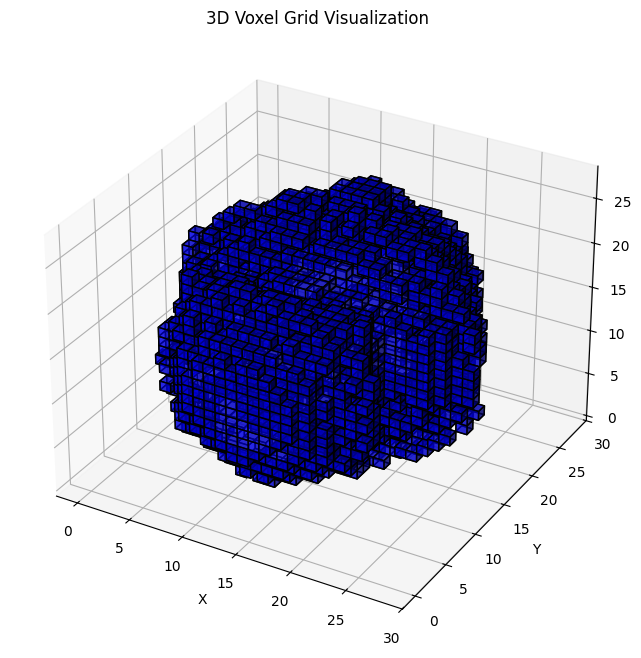

Visualizing generated point cloud histogram (voxel grid)...


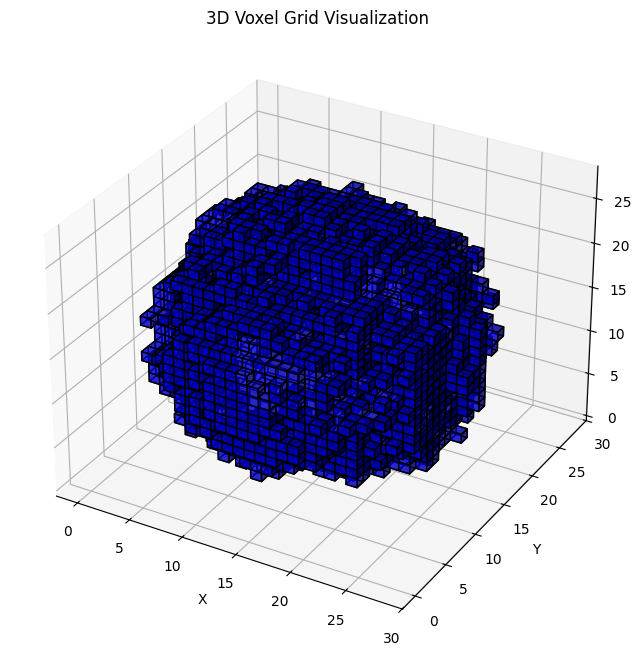

Visualizing reference point cloud histogram (3D bars)...


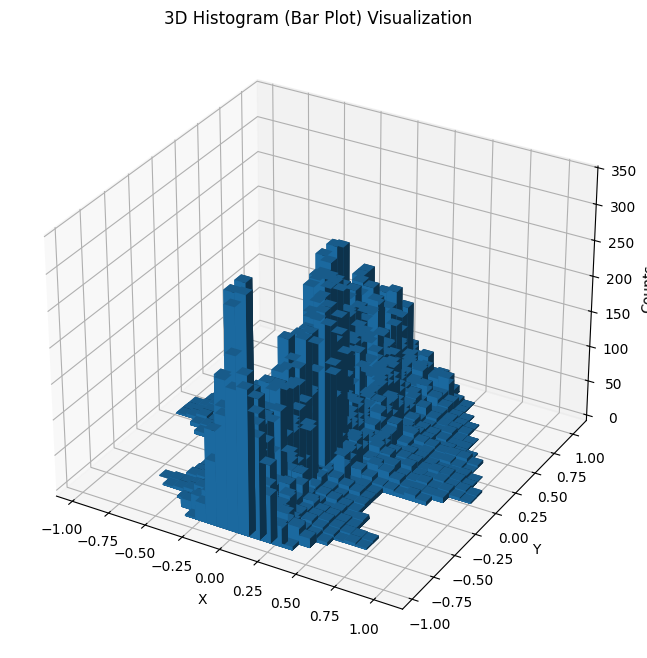

Visualizing generated point cloud histogram (3D bars)...


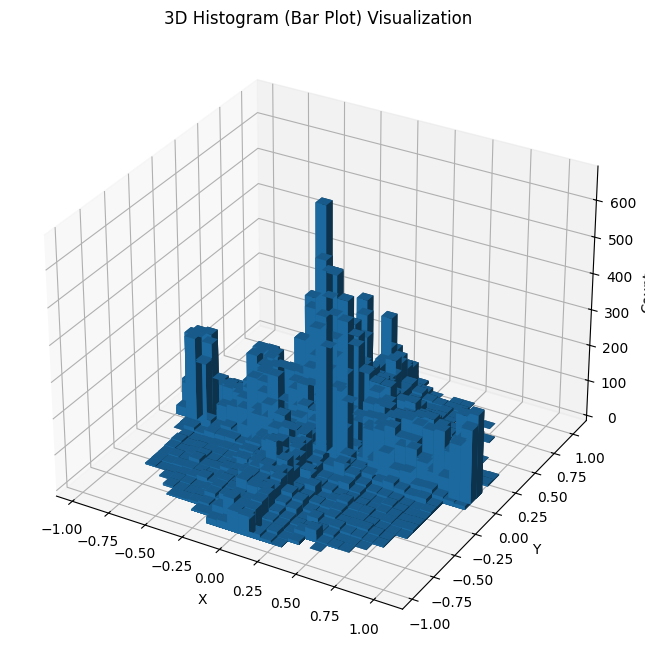

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

# --- Visualization Functions ---

def visualize_voxel_grid(hist, bins, ranges, threshold=0):
    """
    Visualize a 3D histogram as a voxel grid.
    
    Parameters
    ----------
    hist : np.ndarray
        3D histogram from np.histogramdd.
    bins : tuple of ints
        Number of bins in each dimension, e.g., (28,28,28).
    ranges : tuple of tuples
        Ranges for each dimension, e.g., ((-1,1), (-1,1), (-1,1)).
    threshold : float
        Only display voxels with counts greater than threshold.
    """
    # Create bin edges for each axis.
    xedges = np.linspace(ranges[0][0], ranges[0][1], bins[0] + 1)
    yedges = np.linspace(ranges[1][0], ranges[1][1], bins[1] + 1)
    zedges = np.linspace(ranges[2][0], ranges[2][1], bins[2] + 1)
    
    # Compute occupancy grid by thresholding the histogram.
    occupancy = hist > threshold

    # For visualization, calculate bin centers.
    xcenters = (xedges[:-1] + xedges[1:]) / 2.0
    ycenters = (yedges[:-1] + yedges[1:]) / 2.0
    zcenters = (zedges[:-1] + zedges[1:]) / 2.0
    X, Y, Z = np.meshgrid(xcenters, ycenters, zcenters, indexing='ij')
    
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot voxel grid.
    ax.voxels(occupancy, facecolors='blue', edgecolor='k', alpha=0.6)
    
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.title("3D Voxel Grid Visualization")
    plt.show()

def visualize_3d_histogram_bars(hist, bins, ranges, title):
    """
    Visualize a 3D histogram as a 3D bar plot.
    
    Parameters
    ----------
    hist : np.ndarray
        The 3D histogram from np.histogramdd.
    bins : tuple of ints
        Number of bins per axis, e.g., (28,28,28).
    ranges : tuple of tuples
        Ranges for each axis, e.g., ((-1,1), (-1,1), (-1,1)).
    """
    # Compute bin edges.
    xedges = np.linspace(ranges[0][0], ranges[0][1], bins[0] + 1)
    yedges = np.linspace(ranges[1][0], ranges[1][1], bins[1] + 1)
    zedges = np.linspace(ranges[2][0], ranges[2][1], bins[2] + 1)
    
    # Compute bin centers.
    x_centers = (xedges[:-1] + xedges[1:]) / 2.0
    y_centers = (yedges[:-1] + yedges[1:]) / 2.0
    z_centers = (zedges[:-1] + zedges[1:]) / 2.0
    
    # Create a 3D grid of centers.
    X, Y, Z = np.meshgrid(x_centers, y_centers, z_centers, indexing='ij')
    
    # Flatten the grid and histogram.
    xpos = X.ravel()
    ypos = Y.ravel()
    zpos = Z.ravel()
    counts = hist.ravel()
    
    # Optionally filter out empty bins to reduce clutter.
    nonzero = counts > 0
    xpos = xpos[nonzero]
    ypos = ypos[nonzero]
    zpos = zpos[nonzero]
    counts = counts[nonzero]
    
    # Determine the size of each bin.
    dx = (xedges[1] - xedges[0])
    dy = (yedges[1] - yedges[0])
    dz = (zedges[1] - zedges[0])
    
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.bar3d(xpos, ypos, zpos, dx, dy, counts, shade=True)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Counts")
    plt.title(f"3D Histogram (Bar Plot) Visualization of {title}")
    plt.show()

# --- Processing and Visualization for the Two Sets ---

# Merge all point clouds in each set into a single array of shape (total_points, 3).
reference_points_merged = normalized_reference_point_clouds.reshape(-1, 3)
generated_points_merged = normalized_generated_point_clouds.reshape(-1, 3)

# Define the histogram parameters.
bins = (28, 28, 28)
ranges = ((-1, 1), (-1, 1), (-1, 1))

# Compute the 3D histograms.
hist_ref, _ = np.histogramdd(reference_points_merged, bins=bins, range=ranges)
hist_gen, _ = np.histogramdd(generated_points_merged, bins=bins, range=ranges)

# Visualize the reference point cloud histogram as a voxel grid.
print("Visualizing reference point cloud histogram (voxel grid)...")
visualize_voxel_grid(hist_ref, bins, ranges, threshold=0)

# Visualize the generated point cloud histogram as a voxel grid.
print("Visualizing generated point cloud histogram (voxel grid)...")
visualize_voxel_grid(hist_gen, bins, ranges, threshold=0)

# Alternatively, visualize as 3D bar plots.
print("Visualizing reference point cloud histogram (3D bars)...")
visualize_3d_histogram_bars(hist_ref, bins, ranges, "reference point clouds")

print("Visualizing generated point cloud histogram (3D bars)...")
visualize_3d_histogram_bars(hist_gen, bins, ranges, "generated point clouds")